<a href="https://colab.research.google.com/github/Ajaykakade24/PRODIGY_WD_02/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#1missing value counting

In [3]:
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Check missing values
print("Matches Dataset:")
print(matches.isnull().sum())

print("Deliveries Dataset:")
print(deliveries.isnull().sum())

# Drop rows where winner is missing
matches.dropna(subset=["winner"], inplace=True)

# Fill missing bowler names
deliveries["bowler"].fillna("Unknown", inplace=True)

# Fill dismissal-related null values
deliveries["dismissal_kind"].fillna("Not Out", inplace=True)
deliveries["player_dismissed"].fillna("None", inplace=True)

print("Missing values after cleaning:")
print(deliveries.isnull().sum())

Matches Dataset:
match_id         0
season           0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           1
dtype: int64
Deliveries Dataset:
match_id              0
over                  0
ball                  0
batsman               0
bowler                1
batsman_runs          0
extra_runs            0
total_runs            0
dismissal_kind      108
player_dismissed    108
dtype: int64
Missing values after cleaning:
match_id            0
over                0
ball                0
batsman             0
bowler              0
batsman_runs        0
extra_runs          0
total_runs          0
dismissal_kind      0
player_dismissed    0
dtype: int64


/tmp/ipykernel_5459/3709026457.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries["bowler"].fillna("Unknown", inplace=True)
/tmp/ipykernel_5459/3709026457.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [4]:
#Q2 Strike Rate Engine (NumPy Vectorization)

In [5]:
import numpy as np

deliveries = pd.read_csv("deliveries.csv")

# Batting statistics
batting_stats = deliveries.groupby("batsman").agg(
    runs=("batsman_runs", "sum"),
    balls=("ball", "count"),
    matches=("match_id", "nunique")
).reset_index()

# Players with more than 20 matches
batting_stats = batting_stats[batting_stats["matches"] > 20]

# Vectorized Strike Rate Calculation
batting_stats["strike_rate"] = np.divide(
    batting_stats["runs"],
    batting_stats["balls"]
) * 100

# Display result
print(
    batting_stats[
        ["batsman", "matches", "runs", "balls", "strike_rate"]
    ].sort_values(
        by="strike_rate",
        ascending=False
    )
)

Empty DataFrame
Columns: [batsman, matches, runs, balls, strike_rate]
Index: []


In [6]:
# Q3 The Finisher's Profile

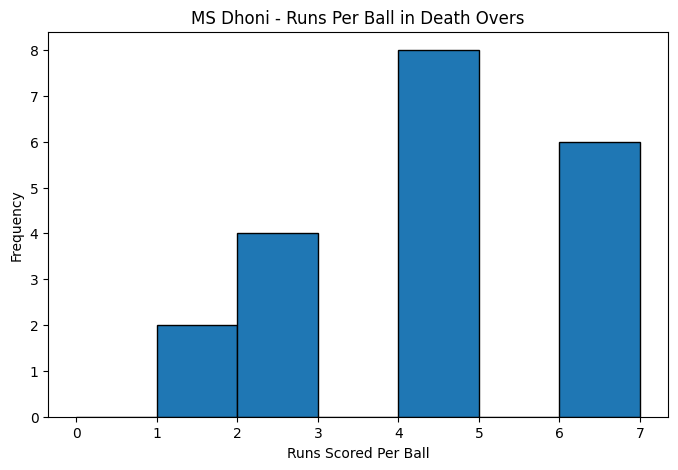

In [7]:
import matplotlib.pyplot as plt

# Load data
deliveries = pd.read_csv("deliveries.csv")

# Select player
player_name = "MS Dhoni"      # Change to "Rinku Singh" if available

# Death overs (16-20)
death_overs = deliveries[
    (deliveries["over"] >= 16) &
    (deliveries["over"] <= 20) &
    (deliveries["batsman"] == player_name)
]

# Histogram of runs scored per ball
plt.figure(figsize=(8,5))
plt.hist(death_overs["batsman_runs"], bins=[0,1,2,3,4,5,6,7], edgecolor="black")

plt.title(f"{player_name} - Runs Per Ball in Death Overs")
plt.xlabel("Runs Scored Per Ball")
plt.ylabel("Frequency")

plt.show()

In [8]:
#Q 4. The Economy Check

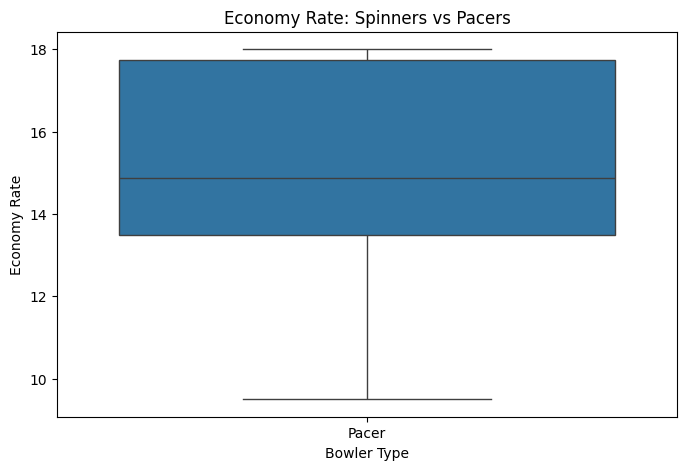

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
deliveries = pd.read_csv("deliveries.csv")

# Economy Rate
economy = deliveries.groupby("bowler").agg(
    runs_conceded=("total_runs", "sum"),
    balls_bowled=("ball", "count")
).reset_index()

economy["economy_rate"] = (
    economy["runs_conceded"] /
    (economy["balls_bowled"] / 6)
)

# Manually classify bowlers
spin_bowlers = [
    "R Ashwin", "R Jadeja", "YS Chahal",
    "Kuldeep Yadav", "A Mishra"
]

economy["bowler_type"] = economy["bowler"].apply(
    lambda x: "Spinner" if x in spin_bowlers else "Pacer"
)

# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=economy,
    x="bowler_type",
    y="economy_rate"
)

plt.title("Economy Rate: Spinners vs Pacers")
plt.xlabel("Bowler Type")
plt.ylabel("Economy Rate")

plt.show()

In [10]:
#Q5. Batting Average vs Strike Rate

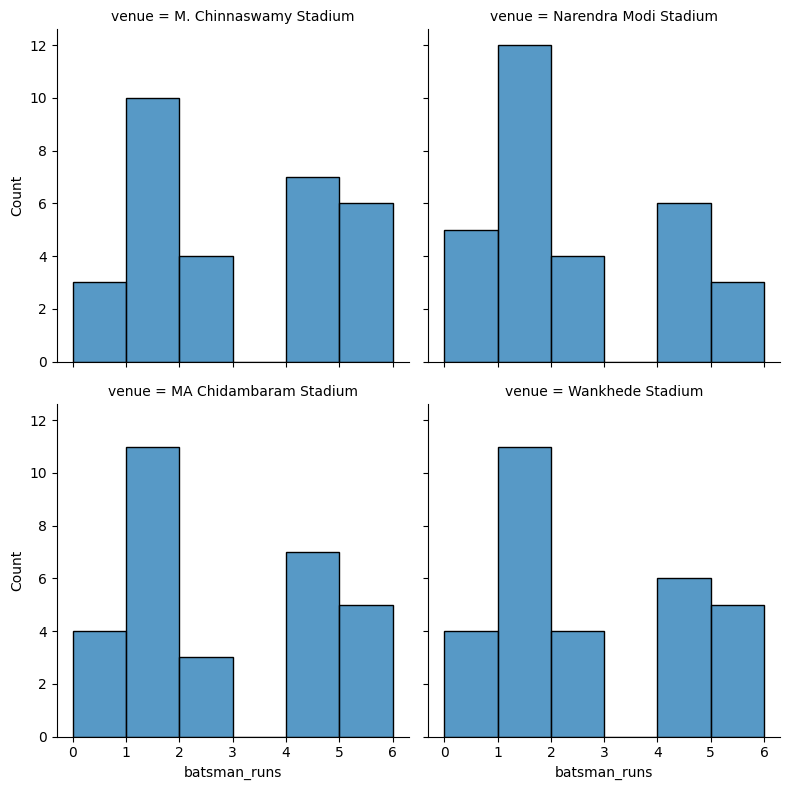

In [11]:
merged = pd.merge(
    deliveries,
    matches[['match_id','venue']],
    on='match_id'
)

g = sns.FacetGrid(
    merged,
    col='venue',
    height=4,
    col_wrap=2
)

g.map(
    sns.histplot,
    'batsman_runs'
)

plt.show()